# 04c — Equity Framework: Gini, Lorenz, Palma, Concentration Index & Vulnerability Index

**Purpose:** Compute formal equity metrics aligned with DfT/ONS/OECD frameworks.
This is the analytical heart of the platform — every policy recommendation depends on equity evidence.

**Inputs:**
- `data/audit/master_lsoa_table.parquet` — 9 socio-economic factors (incl. disability from 03a)
- `data/audit/lsoa_service_levels.parquet` — trip counts from 02g
- `data/audit/lsoa_accessibility.parquet` — stop proximity + access score from 02h
- `data/audit/lsoa_service_quality.parquet` — headway, isolation flags, SQI from 04b

**Outputs:**
- `data/audit/lsoa_equity_metrics.parquet` — per-LSOA equity indicators
- `data/audit/equity_summary.json` — national-level equity statistics

**Key metrics:**
- Gini coefficient of bus service distribution
- Lorenz curve (bottom 20% population → what % of service?)
- Palma ratio (top 10% / bottom 40%)
- Concentration Index (pro-poor vs pro-rich — sign is THE policy finding)
- Vulnerability Index (5-factor composite)
- Triple/quadruple deprivation intersectionality

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from loguru import logger

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

AUDIT = Path('../data/audit')

logger.info('04c_equity_framework starting')

2026-03-14 01:11:51.963 | INFO     | __main__:<module>:17 - 04c_equity_framework starting


## 1. Load and Assemble Inputs

In [2]:
master = pd.read_parquet(AUDIT / 'master_lsoa_table.parquet')
svc = pd.read_parquet(AUDIT / 'lsoa_service_levels.parquet')
acc = pd.read_parquet(AUDIT / 'lsoa_accessibility.parquet')
sq = pd.read_parquet(AUDIT / 'lsoa_service_quality.parquet')

print(f'master: {master.shape}')
print(f'lsoa_service_levels: {svc.shape}')
print(f'lsoa_accessibility: {acc.shape}')
print(f'lsoa_service_quality: {sq.shape}')

master: (33755, 50)
lsoa_service_levels: (33755, 17)
lsoa_accessibility: (33755, 11)
lsoa_service_quality: (33755, 28)


In [3]:
# Assemble unified per-LSOA frame
# Canonical key: lsoa_cd (master) = lsoa_cd (svc) = LSOA21CD (acc, sq)

df = master.copy()

# NOTE: lsoa_service_levels.parquet total_weekday_trips is all-zero (skeleton from 02g).
# Real trip counts live in lsoa_service_quality.parquet as total_weekday_departures.
# We source trips from sq; svc is still merged for stop_count only.
svc_slim = svc[['lsoa_cd', 'stop_count']].copy()
df = df.merge(svc_slim, on='lsoa_cd', how='left', suffixes=('', '_svc'))

# Merge accessibility
acc_slim = acc[['LSOA21CD', 'dist_nearest_stop_m', 'access_score']].rename(
    columns={'LSOA21CD': 'lsoa_cd'}
)
df = df.merge(acc_slim, on='lsoa_cd', how='left')

# Merge service quality — this carries the authoritative trip counts
sq_slim = sq[['LSOA21CD', 'service_quality_index', 'mean_headway_min',
               'evening_isolated', 'sunday_desert', 'no_service', 'archetype',
               'total_weekday_departures', 'total_sunday_departures']].rename(
    columns={'LSOA21CD': 'lsoa_cd'}
)
df = df.merge(sq_slim, on='lsoa_cd', how='left')

# Expose as canonical names so downstream cells need no changes
df['total_weekday_trips'] = df['total_weekday_departures'].fillna(0)
df['total_sunday_trips'] = df['total_sunday_departures'].fillna(0)

# Population denominator: total England (locked GT)
ENGLAND_POP = 56_490_056

# Trips per capita (population denominator = LSOA population from master)
df['trips_per_capita'] = np.where(
    df['population'] > 0,
    df['total_weekday_trips'] / df['population'],
    0.0
)

assert len(df) == 33_755, f'FAIL: expected 33,755 rows, got {len(df)}'
print(f'Assembled frame: {df.shape}')
print(f'Nulls in trips_per_capita: {df["trips_per_capita"].isna().sum()}')
print(f'Zero trips_per_capita: {(df["trips_per_capita"] == 0).sum():,} LSOAs')
print(f'Total weekday trips: {df["total_weekday_trips"].sum():,.0f}')
print(f'Max trips_per_capita: {df["trips_per_capita"].max():.2f}')


Assembled frame: (33755, 64)
Nulls in trips_per_capita: 0
Zero trips_per_capita: 1,793 LSOAs
Total weekday trips: 14,458,634
Max trips_per_capita: 22.90


## 2. Gini Coefficient

In [4]:
def gini_coefficient(values: np.ndarray, weights: np.ndarray | None = None) -> float:
    """Compute the Gini coefficient, optionally population-weighted.
    
    Args:
        values: Non-negative values (e.g. trips per capita per LSOA).
        weights: Population weights. If None, equal weights assumed.
    
    Returns:
        Gini coefficient in [0, 1].
    """
    values = np.asarray(values, dtype=float)
    if weights is None:
        weights = np.ones_like(values)
    weights = np.asarray(weights, dtype=float)

    # Sort by value
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    # Cumulative shares
    cum_w = np.cumsum(weights)
    total_w = cum_w[-1]
    cum_v = np.cumsum(values * weights)
    total_v = cum_v[-1]

    if total_v == 0:
        return 1.0  # all zeros = maximum inequality (no one gets anything)

    # Area under Lorenz curve (trapezoidal)
    lorenz_x = np.concatenate([[0], cum_w / total_w])
    lorenz_y = np.concatenate([[0], cum_v / total_v])
    # np.trapezoid is the NumPy 2.x name; np.trapz was removed in NumPy 2.0
    _trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
    area_under = _trapz(lorenz_y, lorenz_x)
    return float(1 - 2 * area_under)


valid = df.dropna(subset=['trips_per_capita', 'population'])
gini_unweighted = gini_coefficient(valid['trips_per_capita'].values)
gini_weighted = gini_coefficient(valid['trips_per_capita'].values, valid['population'].values)

print(f'Gini coefficient (unweighted, per LSOA): {gini_unweighted:.4f}')
print(f'Gini coefficient (population-weighted): {gini_weighted:.4f}')
print(f'Interpretation: 0 = perfect equality, 1 = maximum inequality')
print(f'Reference: UK income Gini ≈ 0.36; transport Gini of {gini_weighted:.2f} suggests {"high" if gini_weighted > 0.5 else "moderate"} inequality')


Gini coefficient (unweighted, per LSOA): 0.5739
Gini coefficient (population-weighted): 0.5741
Interpretation: 0 = perfect equality, 1 = maximum inequality
Reference: UK income Gini ≈ 0.36; transport Gini of 0.57 suggests high inequality


## 3. Lorenz Curve

Bottom 20% of population (lowest-served) receives: 1.4% of all bus service
Bottom 40% of population receives: 7.3% of all bus service
Top 10% of population (highest-served) receives: 41.7% of all bus service


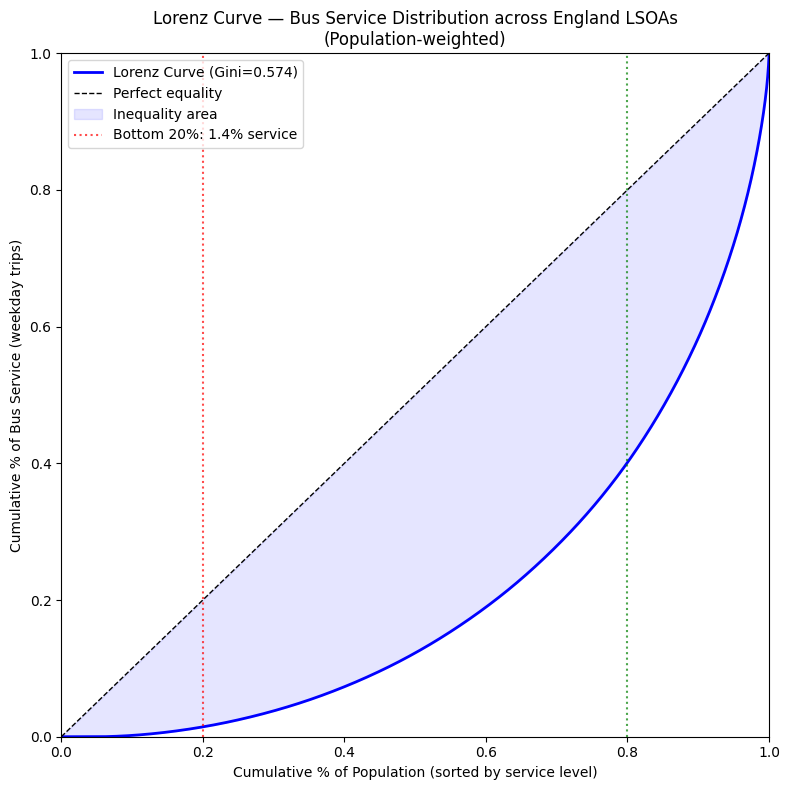

Saved fig_04c_lorenz_curve.png


In [5]:
# Population-weighted Lorenz curve
# Sort by service level (trips per capita), accumulate population share and service share

lorenz_df = valid[['trips_per_capita', 'population']].copy().sort_values('trips_per_capita')
lorenz_df['cum_pop'] = lorenz_df['population'].cumsum() / lorenz_df['population'].sum()
lorenz_df['cum_trips'] = (lorenz_df['trips_per_capita'] * lorenz_df['population']).cumsum()
lorenz_df['cum_trips'] /= lorenz_df['cum_trips'].iloc[-1]

# Add origin
lorenz_x = np.concatenate([[0], lorenz_df['cum_pop'].values])
lorenz_y = np.concatenate([[0], lorenz_df['cum_trips'].values])

# Bottom 20% of population gets what % of service?
bottom_20_service = float(np.interp(0.20, lorenz_x, lorenz_y)) * 100
bottom_40_service = float(np.interp(0.40, lorenz_x, lorenz_y)) * 100
top_10_service = (1 - float(np.interp(0.90, lorenz_x, lorenz_y))) * 100

print(f'Bottom 20% of population (lowest-served) receives: {bottom_20_service:.1f}% of all bus service')
print(f'Bottom 40% of population receives: {bottom_40_service:.1f}% of all bus service')
print(f'Top 10% of population (highest-served) receives: {top_10_service:.1f}% of all bus service')

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lorenz_x, lorenz_y, 'b-', linewidth=2, label=f'Lorenz Curve (Gini={gini_weighted:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
ax.fill_between(lorenz_x, lorenz_y, lorenz_x, alpha=0.1, color='blue', label='Inequality area')
ax.axvline(0.20, color='red', linestyle=':', alpha=0.7, label=f'Bottom 20%: {bottom_20_service:.1f}% service')
ax.axvline(0.80, color='green', linestyle=':', alpha=0.7)
ax.set_xlabel('Cumulative % of Population (sorted by service level)')
ax.set_ylabel('Cumulative % of Bus Service (weekday trips)')
ax.set_title('Lorenz Curve — Bus Service Distribution across England LSOAs\n(Population-weighted)')
ax.legend(loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(AUDIT / 'fig_04c_lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04c_lorenz_curve.png')

## 4. Palma Ratio

In [6]:
# Palma ratio: top 10% service share / bottom 40% service share
# Population-weighted: sort by trips_per_capita, find pop-weighted quintile thresholds

sorted_df = lorenz_df.copy().reset_index(drop=True)
sorted_df['pop_share'] = sorted_df['population'] / sorted_df['population'].sum()
sorted_df['service_share'] = (sorted_df['trips_per_capita'] * sorted_df['population']) / \
    (sorted_df['trips_per_capita'] * sorted_df['population']).sum()

# Find bottom 40% and top 10% by cumulative population share
bottom_40_mask = sorted_df['cum_pop'] <= 0.40
top_10_mask = sorted_df['cum_pop'] >= 0.90

bottom_40_service_share = sorted_df.loc[bottom_40_mask, 'service_share'].sum()
top_10_service_share = sorted_df.loc[top_10_mask, 'service_share'].sum()

palma_ratio = top_10_service_share / bottom_40_service_share if bottom_40_service_share > 0 else float('inf')

print(f'Palma Ratio: {palma_ratio:.3f}')
print(f'  Bottom 40% service share: {bottom_40_service_share * 100:.1f}%')
print(f'  Top 10% service share: {top_10_service_share * 100:.1f}%')
print(f'  Interpretation: top 10% receives {palma_ratio:.2f}× more service than bottom 40%')
print(f'  Palma < 1: pro-poor distribution | > 1: pro-rich distribution')

Palma Ratio: 5.702
  Bottom 40% service share: 7.3%
  Top 10% service share: 41.7%
  Interpretation: top 10% receives 5.70× more service than bottom 40%
  Palma < 1: pro-poor distribution | > 1: pro-rich distribution


## 5. Concentration Index

In [7]:
def concentration_index(health_var: np.ndarray, rank_var: np.ndarray,
                         weights: np.ndarray | None = None) -> float:
    """Compute the Wagstaff Concentration Index.

    CI = 2 * cov(h, r) / mu_h
    where h = health/service variable, r = fractional rank by socio-economic status,
    mu_h = mean of h.

    Negative CI: service concentrated among deprived (pro-poor).
    Positive CI: service concentrated among affluent (pro-rich).

    Args:
        health_var: Service/outcome variable per LSOA.
        rank_var: Socio-economic rank (higher = more affluent for standard CI;
                  here we pass IMD rank where 1 = most deprived, so negative CI = pro-poor).
        weights: Population weights.

    Returns:
        Concentration index in [-1, 1].
    """
    h = np.asarray(health_var, dtype=float)
    r = np.asarray(rank_var, dtype=float)
    if weights is None:
        w = np.ones_like(h)
    else:
        w = np.asarray(weights, dtype=float)

    # Fractional rank: cumulative pop share, centred at midpoint of each individual's range
    total_w = w.sum()
    order = np.argsort(r)  # sort by IMD rank (1=most deprived ... 33755=least deprived)
    w_sorted = w[order]
    h_sorted = h[order]
    cum_w = np.cumsum(w_sorted)
    # Fractional rank = midpoint of cumulative weight share
    frac_rank = (cum_w - w_sorted / 2) / total_w

    mu_h = np.average(h_sorted, weights=w_sorted)
    if mu_h == 0:
        return 0.0

    # Weighted covariance between h and fractional rank
    cov_wh = np.average((h_sorted - mu_h) * (frac_rank - 0.5), weights=w_sorted)
    return float(2 * cov_wh / mu_h)


ci_df = df.dropna(subset=['trips_per_capita', 'imd_rank', 'population'])

# IMD rank: 1 = most deprived. We want CI where positive rank = more affluent.
# Invert rank so that rank increases with affluence
max_rank = ci_df['imd_rank'].max()
ci_df = ci_df.copy()
ci_df['affluence_rank'] = max_rank + 1 - ci_df['imd_rank']

ci_trips = concentration_index(
    ci_df['trips_per_capita'].values,
    ci_df['affluence_rank'].values,
    ci_df['population'].values
)

ci_sqi = concentration_index(
    ci_df['service_quality_index'].fillna(0).values,
    ci_df['affluence_rank'].values,
    ci_df['population'].values
)

print(f'Concentration Index — weekday trips per capita: {ci_trips:.4f}')
print(f'Concentration Index — service quality index: {ci_sqi:.4f}')
print()
if ci_trips < 0:
    print(f'CI = {ci_trips:.4f}: PRO-POOR — bus service is more concentrated among deprived LSOAs')
else:
    print(f'CI = {ci_trips:.4f}: PRO-RICH — bus service is more concentrated among affluent LSOAs')
print()
print('This is THE key policy finding: does bus service favour those who need it most?')

Concentration Index — weekday trips per capita: 0.1358
Concentration Index — service quality index: 0.0527

CI = 0.1358: PRO-RICH — bus service is more concentrated among affluent LSOAs

This is THE key policy finding: does bus service favour those who need it most?


## 6. Dissimilarity Index

In [8]:
# Dissimilarity Index: proportion of bus trips that would need to redistribute
# for every LSOA to have service proportional to its population share.
# DI = 0.5 * sum(|b_i/B - p_i/P|)
# where b_i = trips in LSOA i, B = total trips, p_i = pop of LSOA i, P = total pop

di_df = df.dropna(subset=['total_weekday_trips', 'population'])
di_df = di_df.copy()
total_trips = di_df['total_weekday_trips'].fillna(0).sum()
total_pop = di_df['population'].sum()

di_df['trip_share'] = di_df['total_weekday_trips'].fillna(0) / total_trips
di_df['pop_share'] = di_df['population'] / total_pop

dissimilarity_index = 0.5 * (di_df['trip_share'] - di_df['pop_share']).abs().sum()

print(f'Dissimilarity Index: {dissimilarity_index:.4f}')
print(f'Interpretation: {dissimilarity_index * 100:.1f}% of all bus trips would need to redistribute')
print(f'for every LSOA to have service exactly proportional to its population.')

Dissimilarity Index: 0.4212
Interpretation: 42.1% of all bus trips would need to redistribute
for every LSOA to have service exactly proportional to its population.


## 7. Vulnerability Index

In [9]:
# Vulnerability Index: composite of 5 factors
# Each factor normalised 0–100 (min-max within England) then equally weighted
# Higher score = more vulnerable (higher transport need, lower resilience)
#
# Factors:
# 1. IMD rank (normalised: rank 1 = most deprived → score 100)
# 2. No-car % (higher = more car-free dependency)
# 3. Elderly % (65+ share)
# 4. Disability % (TS038)
# 5. Unemployment rate

vuln_df = df[['lsoa_cd', 'imd_rank', 'nocar_pct', 'elderly_pct',
               'disability_pct', 'unemployment_rate', 'population',
               'imd_decile', 'urban_rural', 'service_quality_index',
               'archetype']].copy()

def minmax_norm(series: pd.Series, invert: bool = False) -> pd.Series:
    """Min-max normalise to 0–100. If invert=True, higher raw = lower score."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(50.0, index=series.index)
    normed = (series - mn) / (mx - mn) * 100
    return (100 - normed) if invert else normed

# IMD rank: rank 1 = most deprived → score 100 (invert rank)
vuln_df['v_imd'] = minmax_norm(vuln_df['imd_rank'], invert=True)
vuln_df['v_nocar'] = minmax_norm(vuln_df['nocar_pct'].fillna(0))
vuln_df['v_elderly'] = minmax_norm(vuln_df['elderly_pct'].fillna(0))
vuln_df['v_disability'] = minmax_norm(vuln_df['disability_pct'].fillna(0))
vuln_df['v_unemployment'] = minmax_norm(vuln_df['unemployment_rate'].fillna(0))

# Equal-weight composite
vuln_df['vulnerability_index'] = (
    vuln_df[['v_imd', 'v_nocar', 'v_elderly', 'v_disability', 'v_unemployment']].mean(axis=1)
).round(1)

print(f'Vulnerability Index range: {vuln_df["vulnerability_index"].min():.1f} – {vuln_df["vulnerability_index"].max():.1f}')
print(f'Mean: {vuln_df["vulnerability_index"].mean():.1f}')
print(f'\nTop 10% most vulnerable LSOAs:')
top_10_pct = vuln_df.nlargest(int(len(vuln_df) * 0.10), 'vulnerability_index')
print(f'  Count: {len(top_10_pct):,}')
print(f'  Mean SQI in top 10% vulnerable: {top_10_pct["service_quality_index"].mean():.1f}')
print(f'  Mean SQI in bottom 10% (least vulnerable): {vuln_df.nsmallest(int(len(vuln_df) * 0.10), "vulnerability_index")["service_quality_index"].mean():.1f}')

Vulnerability Index range: 5.9 – 77.4
Mean: 31.8

Top 10% most vulnerable LSOAs:
  Count: 3,375
  Mean SQI in top 10% vulnerable: 77.1
  Mean SQI in bottom 10% (least vulnerable): 55.7


## 8. Triple & Quadruple Deprivation

In [10]:
# Triple deprivation: top-third on IMD + no-car + elderly simultaneously
# Quadruple: + disability
# Use top tertile (top 33%) of each factor across England LSOAs

imd_thresh = vuln_df['imd_rank'].quantile(0.33)  # lower rank = more deprived
nocar_thresh = vuln_df['nocar_pct'].quantile(0.67)
elderly_thresh = vuln_df['elderly_pct'].quantile(0.67)
disability_thresh = vuln_df['disability_pct'].quantile(0.67)

vuln_df['high_deprivation'] = vuln_df['imd_rank'] <= imd_thresh
vuln_df['high_nocar'] = vuln_df['nocar_pct'] >= nocar_thresh
vuln_df['high_elderly'] = vuln_df['elderly_pct'] >= elderly_thresh
vuln_df['high_disability'] = vuln_df['disability_pct'] >= disability_thresh

vuln_df['triple_deprived'] = (vuln_df['high_deprivation']
                               & vuln_df['high_nocar']
                               & vuln_df['high_elderly'])
vuln_df['quadruple_vulnerable'] = (vuln_df['triple_deprived']
                                    & vuln_df['high_disability'])

n_triple = int(vuln_df['triple_deprived'].sum())
n_quad = int(vuln_df['quadruple_vulnerable'].sum())

print(f'Triple-deprived LSOAs (high IMD + high no-car + high elderly): {n_triple:,} ({n_triple / len(vuln_df) * 100:.1f}%)')
print(f'Quadruple-vulnerable LSOAs (+ high disability): {n_quad:,} ({n_quad / len(vuln_df) * 100:.1f}%)')

# Service quality gap: triple-deprived vs rest
triple_sqi = vuln_df.loc[vuln_df['triple_deprived'], 'service_quality_index'].mean()
rest_sqi = vuln_df.loc[~vuln_df['triple_deprived'], 'service_quality_index'].mean()
quad_sqi = vuln_df.loc[vuln_df['quadruple_vulnerable'], 'service_quality_index'].mean()

print(f'\nMean SQI — triple-deprived: {triple_sqi:.1f}')
print(f'Mean SQI — rest of England: {rest_sqi:.1f}')
print(f'Mean SQI — quadruple-vulnerable: {quad_sqi:.1f}')
print(f'SQI gap (rest − triple-deprived): {rest_sqi - triple_sqi:.1f} points')

Triple-deprived LSOAs (high IMD + high no-car + high elderly): 612 (1.8%)
Quadruple-vulnerable LSOAs (+ high disability): 611 (1.8%)

Mean SQI — triple-deprived: 71.5
Mean SQI — rest of England: 65.3
Mean SQI — quadruple-vulnerable: 71.5
SQI gap (rest − triple-deprived): -6.3 points


## 9. Equity by Archetype and Region

In [11]:
# Gini within each archetype
archetype_equity = {}
for arch, grp in df.dropna(subset=['archetype', 'trips_per_capita', 'population']).groupby('archetype'):
    g = gini_coefficient(grp['trips_per_capita'].values, grp['population'].values)
    archetype_equity[arch] = {
        'gini': round(g, 4),
        'n_lsoas': len(grp),
        'mean_trips_per_capita': round(grp['trips_per_capita'].mean(), 2),
        'mean_sqi': round(grp['service_quality_index'].mean(), 1) if 'service_quality_index' in grp.columns else None,
    }
    print(f'{arch}: Gini={g:.4f}, n={len(grp):,}, mean_tpc={grp["trips_per_capita"].mean():.2f}')

# Regional analysis
region_equity = {}
for region, grp in df.dropna(subset=['region', 'trips_per_capita', 'population']).groupby('region'):
    g = gini_coefficient(grp['trips_per_capita'].values, grp['population'].values)
    ci = concentration_index(
        grp['trips_per_capita'].values,
        (max_rank + 1 - grp['imd_rank'].fillna(grp['imd_rank'].median())).values,
        grp['population'].values
    ) if 'imd_rank' in grp.columns else None
    region_equity[region] = {'gini': round(g, 4), 'ci': round(ci, 4) if ci else None, 'n_lsoas': len(grp)}

print(f'\nRegional Gini:')
for r, stats_r in sorted(region_equity.items(), key=lambda x: x[1]['gini'], reverse=True):
    print(f'  {r}: Gini={stats_r["gini"]:.4f}, CI={stats_r["ci"]}')

Affluent Urban: Gini=0.5421, n=16,944, mean_tpc=0.19
Deprived Car-Free Urban: Gini=0.4778, n=6,200, mean_tpc=0.27
Deprived Young Diverse: Gini=0.5517, n=6,023, mean_tpc=0.48
Elderly Rural: Gini=0.5638, n=4,588, mean_tpc=0.15

Regional Gini:
  Unknown: Gini=0.5741, CI=0.1358


## 10. Policy-Actionable Summary

In [12]:
# What would happen to Gini if bottom deprivation decile was brought to median service?
median_trips_pc = df['trips_per_capita'].median()

# Bottom deprivation decile = IMD decile 1 (most deprived)
df_scenario = df.copy()
bottom_decile_mask = df_scenario['imd_decile'] == 1

# Count those below median in bottom decile
below_median_count = (bottom_decile_mask & (df_scenario['trips_per_capita'] < median_trips_pc)).sum()

# Simulate bringing them to median
df_scenario.loc[bottom_decile_mask & (df_scenario['trips_per_capita'] < median_trips_pc),
                'trips_per_capita'] = median_trips_pc

valid_scenario = df_scenario.dropna(subset=['trips_per_capita', 'population'])
gini_after = gini_coefficient(valid_scenario['trips_per_capita'].values, valid_scenario['population'].values)
gini_change = gini_weighted - gini_after

print(f'Policy scenario: bring bottom IMD decile to median service')
print(f'  LSOAs affected: {below_median_count:,}')
print(f'  Gini before: {gini_weighted:.4f}')
print(f'  Gini after: {gini_after:.4f}')
print(f'  Gini change: {gini_change:+.4f} ({gini_change / gini_weighted * 100:+.1f}%)')

Policy scenario: bring bottom IMD decile to median service
  LSOAs affected: 1,102
  Gini before: 0.5741
  Gini after: 0.5658
  Gini change: +0.0084 (+1.5%)


## 11. Visualisations

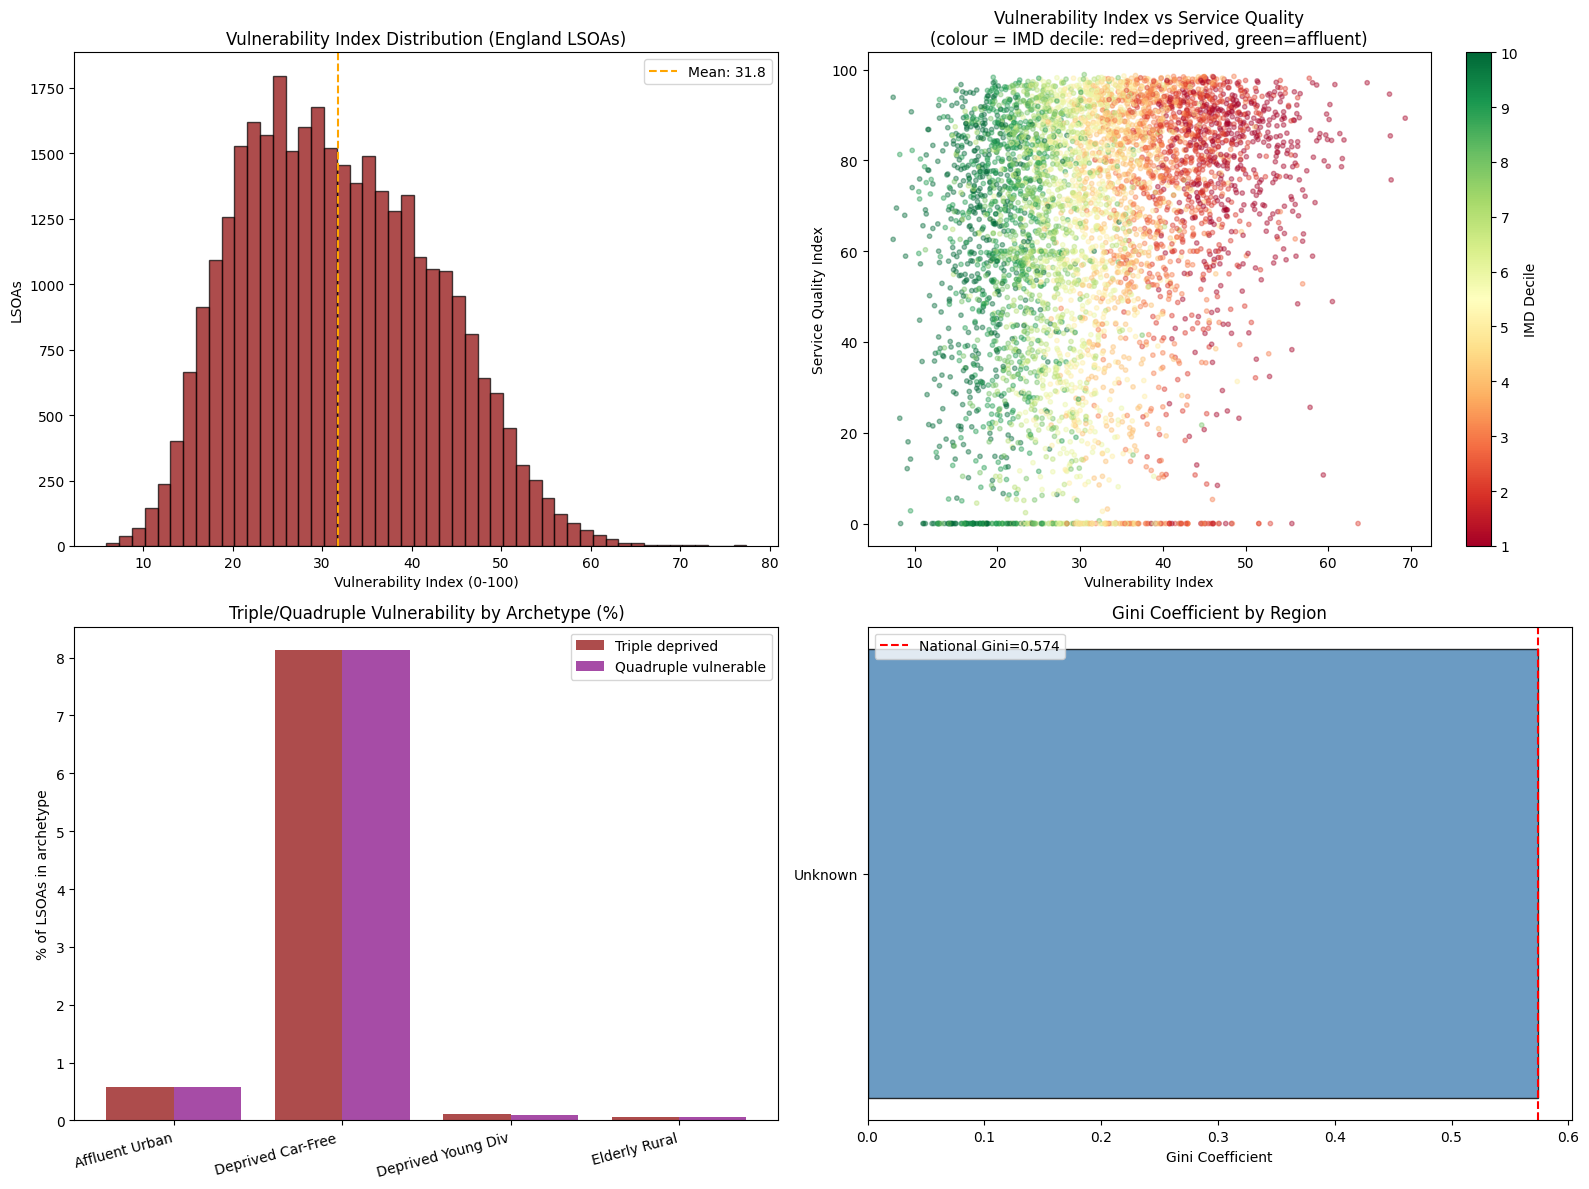

Saved fig_04c_equity_summary.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vulnerability index distribution
axes[0, 0].hist(vuln_df['vulnerability_index'], bins=50, edgecolor='black', alpha=0.7, color='darkred')
axes[0, 0].axvline(vuln_df['vulnerability_index'].mean(), color='orange', linestyle='--',
                   label=f'Mean: {vuln_df["vulnerability_index"].mean():.1f}')
axes[0, 0].set_title('Vulnerability Index Distribution (England LSOAs)')
axes[0, 0].set_xlabel('Vulnerability Index (0-100)')
axes[0, 0].set_ylabel('LSOAs')
axes[0, 0].legend()

# Vulnerability vs service quality
sample_idx = np.random.choice(len(vuln_df.dropna(subset=['vulnerability_index', 'service_quality_index'])),
                               size=min(5000, len(vuln_df)), replace=False)
plot_df = vuln_df.dropna(subset=['vulnerability_index', 'service_quality_index']).iloc[sample_idx]
scatter_colors = plot_df['imd_decile'].map(
    lambda x: plt.cm.RdYlGn(x / 10) if pd.notna(x) else (0.5, 0.5, 0.5, 0.3)
)
axes[0, 1].scatter(plot_df['vulnerability_index'], plot_df['service_quality_index'],
                   c=plot_df['imd_decile'], cmap='RdYlGn', alpha=0.4, s=10)
axes[0, 1].set_title('Vulnerability Index vs Service Quality\n(colour = IMD decile: red=deprived, green=affluent)')
axes[0, 1].set_xlabel('Vulnerability Index')
axes[0, 1].set_ylabel('Service Quality Index')
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(1, 10))
plt.colorbar(sm, ax=axes[0, 1], label='IMD Decile')

# Triple/quadruple deprivation by archetype
if 'archetype' in vuln_df.columns:
    arch_vuln = vuln_df.groupby('archetype', observed=True)[['triple_deprived', 'quadruple_vulnerable']].mean() * 100
    x = np.arange(len(arch_vuln))
    axes[1, 0].bar(x - 0.2, arch_vuln['triple_deprived'], 0.4, label='Triple deprived', color='darkred', alpha=0.7)
    axes[1, 0].bar(x + 0.2, arch_vuln['quadruple_vulnerable'], 0.4, label='Quadruple vulnerable', color='purple', alpha=0.7)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels([a[:18] for a in arch_vuln.index], rotation=15, ha='right')
    axes[1, 0].set_title('Triple/Quadruple Vulnerability by Archetype (%)')
    axes[1, 0].set_ylabel('% of LSOAs in archetype')
    axes[1, 0].legend()

# Gini by region
if region_equity:
    reg_ginis = pd.Series({r: v['gini'] for r, v in region_equity.items()}).sort_values(ascending=False)
    axes[1, 1].barh(reg_ginis.index, reg_ginis.values, color='steelblue', edgecolor='black', alpha=0.8)
    axes[1, 1].axvline(gini_weighted, color='red', linestyle='--', label=f'National Gini={gini_weighted:.3f}')
    axes[1, 1].set_title('Gini Coefficient by Region')
    axes[1, 1].set_xlabel('Gini Coefficient')
    axes[1, 1].legend()

plt.tight_layout()
plt.savefig(AUDIT / 'fig_04c_equity_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04c_equity_summary.png')

## 12. Save Outputs

In [14]:
# lsoa_equity_metrics: per-LSOA
equity_cols = ['lsoa_cd', 'v_imd', 'v_nocar', 'v_elderly', 'v_disability', 'v_unemployment',
                'vulnerability_index', 'high_deprivation', 'high_nocar', 'high_elderly',
                'high_disability', 'triple_deprived', 'quadruple_vulnerable']
lsoa_equity = vuln_df[equity_cols].copy()

# Merge trips_per_capita for reference
lsoa_equity = lsoa_equity.merge(
    df[['lsoa_cd', 'trips_per_capita', 'service_quality_index', 'imd_decile', 'population', 'urban_rural']],
    on='lsoa_cd', how='left'
)

lsoa_equity.to_parquet(AUDIT / 'lsoa_equity_metrics.parquet', index=False)
print(f'Saved lsoa_equity_metrics.parquet: {lsoa_equity.shape}')

# equity_summary.json: national-level stats
equity_summary = {
    'gini_unweighted': round(gini_unweighted, 4),
    'gini_population_weighted': round(gini_weighted, 4),
    'gini_after_bottom_decile_uplift': round(gini_after, 4),
    'gini_change_from_policy': round(gini_change, 4),
    'palma_ratio': round(palma_ratio, 3),
    'bottom_40_service_share_pct': round(bottom_40_service_share * 100, 1),
    'top_10_service_share_pct': round(top_10_service_share * 100, 1),
    'bottom_20_population_service_share_pct': round(bottom_20_service, 1),
    'concentration_index_trips': round(ci_trips, 4),
    'concentration_index_sqi': round(ci_sqi, 4),
    'dissimilarity_index': round(dissimilarity_index, 4),
    'triple_deprived_lsoas': n_triple,
    'triple_deprived_pct': round(n_triple / 33_755 * 100, 1),
    'quadruple_vulnerable_lsoas': n_quad,
    'quadruple_vulnerable_pct': round(n_quad / 33_755 * 100, 1),
    'sqi_gap_triple_vs_rest': round(rest_sqi - triple_sqi, 1),
    'archetype_equity': archetype_equity,
    'regional_equity': region_equity,
    'lorenz_x': lorenz_x.tolist(),
    'lorenz_y': lorenz_y.tolist(),
}

with open(AUDIT / 'equity_summary.json', 'w') as f:
    json.dump(equity_summary, f, indent=2)
print(f'Saved equity_summary.json')
print(f'Key values: Gini={gini_weighted:.4f}, Palma={palma_ratio:.3f}, CI={ci_trips:.4f}')

Saved lsoa_equity_metrics.parquet: (33755, 18)
Saved equity_summary.json
Key values: Gini=0.5741, Palma=5.702, CI=0.1358


## 13. Validation Summary

In [15]:
checks = [
    ('All 33,755 LSOAs in equity metrics',
     len(lsoa_equity) == 33_755,
     f'{len(lsoa_equity):,}'),
    ('Gini in valid range (0–1)',
     0 < gini_weighted < 1,
     f'{gini_weighted:.4f}'),
    ('Palma ratio > 0',
     palma_ratio > 0,
     f'{palma_ratio:.3f}'),
    ('Dissimilarity index in (0, 1)',
     0 < dissimilarity_index < 1,
     f'{dissimilarity_index:.4f}'),
    ('Vulnerability index range 0–100',
     lsoa_equity['vulnerability_index'].between(0, 100).all(),
     f'min={lsoa_equity["vulnerability_index"].min():.1f}, max={lsoa_equity["vulnerability_index"].max():.1f}'),
    ('Triple-deprived LSOAs > 0',
     n_triple > 0,
     f'{n_triple:,} ({n_triple / 33_755 * 100:.1f}%)'),
    ('Quadruple-vulnerable LSOAs > 0',
     n_quad > 0,
     f'{n_quad:,} ({n_quad / 33_755 * 100:.1f}%)'),
    ('lsoa_equity_metrics.parquet saved',
     (AUDIT / 'lsoa_equity_metrics.parquet').exists(),
     'exists'),
    ('equity_summary.json saved',
     (AUDIT / 'equity_summary.json').exists(),
     'exists'),
]

print('=== 04c Validation Checks ===')
fail_count = 0
for name, result, detail in checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        fail_count += 1
    print(f'  [{status}] {name} — {detail}')

assert fail_count == 0, f'{fail_count} checks FAILED'

print(f'\n04c COMPLETE: {len(checks)} checks, all PASS')
print(f'  Gini (pop-weighted): {gini_weighted:.4f}')
print(f'  Palma ratio: {palma_ratio:.3f}')
print(f'  Concentration Index (trips): {ci_trips:.4f} ({"PRO-POOR" if ci_trips < 0 else "PRO-RICH"})')
print(f'  Dissimilarity Index: {dissimilarity_index:.4f}')
print(f'  Triple-deprived LSOAs: {n_triple:,}')
print(f'  Quadruple-vulnerable LSOAs: {n_quad:,}')
print(f'  SQI gap (triple vs rest): {rest_sqi - triple_sqi:.1f} points')

logger.info(f'04c complete — gini={gini_weighted:.4f}, palma={palma_ratio:.3f}, ci={ci_trips:.4f}, '
            f'triple_deprived={n_triple}, quad_vuln={n_quad}')

2026-03-14 01:11:53.196 | INFO     | __main__:<module>:50 - 04c complete — gini=0.5741, palma=5.702, ci=0.1358, triple_deprived=612, quad_vuln=611


=== 04c Validation Checks ===
  [PASS] All 33,755 LSOAs in equity metrics — 33,755
  [PASS] Gini in valid range (0–1) — 0.5741
  [PASS] Palma ratio > 0 — 5.702
  [PASS] Dissimilarity index in (0, 1) — 0.4212
  [PASS] Vulnerability index range 0–100 — min=5.9, max=77.4
  [PASS] Triple-deprived LSOAs > 0 — 612 (1.8%)
  [PASS] Quadruple-vulnerable LSOAs > 0 — 611 (1.8%)
  [PASS] lsoa_equity_metrics.parquet saved — exists
  [PASS] equity_summary.json saved — exists

04c COMPLETE: 9 checks, all PASS
  Gini (pop-weighted): 0.5741
  Palma ratio: 5.702
  Concentration Index (trips): 0.1358 (PRO-RICH)
  Dissimilarity Index: 0.4212
  Triple-deprived LSOAs: 612
  Quadruple-vulnerable LSOAs: 611
  SQI gap (triple vs rest): -6.3 points
